## Section 6 — Evaluation & Comparison

Score the three classifiers trained in Section 5 on the **identical held-out test set** — the untouched Oxford-IIIT Pet `test` split, 3 669 images that no stage of the pipeline has seen: not the captioner (2), not the paraphraser (3), not SD-Turbo (4), and not the CLIP filter (4.2).

| Run | Training data | Checkpoint |
|-----|---------------|------------|
| `baseline` | real training images only | `checkpoints/baseline_resnet18.pt` |
| `augmented` | real + **all** synthetic images | `checkpoints/augmented_resnet18.pt` |
| `augmented_filtered` | real + **CLIP-filtered** synthetic images | `checkpoints/augmented_filtered_resnet18.pt` |

Each run is scored with accuracy plus precision / recall / F1 in both **macro** (every breed counts the same — the honest read when the question is whether augmentation helped the *weak* classes) and **weighted** (support-weighted, closer to raw accuracy) averages, then per class. The section then builds the comparison table and chart, tests whether the differences between runs are distinguishable from chance (6.6), and closes with the written discussion of what the whole pipeline demonstrated (6.7).

This notebook assumes **05_ClassifierTraining.ipynb has already been run** and left its checkpoints in `checkpoints/` and its histories in `reports/`.

In [10]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt
from tqdm import tqdm


def get_device() -> torch.device:
    """Resolve the best available torch device, preferring CUDA, then Apple MPS, then CPU.

    Returns:
        torch.device: the selected device for model inference.
    """
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def set_global_seed(seed: int) -> None:
    """Seed Python, NumPy and PyTorch RNGs for reproducible runs.

    Args:
        seed: the seed value applied to all random number generators.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


DATA_ROOT = Path("data")
CHECKPOINTS_DIR = Path("checkpoints")
REPORTS_DIR = Path("reports")
REPORTS_DIR.mkdir(exist_ok=True)
SEED = 42
DEVICE = get_device()

set_global_seed(SEED)

print(f"Using device: {DEVICE}")

Using device: mps


### 6.1 Loading the test set and the trained classifiers

The test loader is built straight from `torchvision`'s `OxfordIIITPet` with the *same* deterministic transform Section 5 used (resize → tensor → ImageNet normalisation, no random augmentation). Section 5 routed its images through `ManifestImageDataset` because its training indices mix real and synthetic rows; here every row is real, so indexing the dataset directly is equivalent and avoids re-declaring that class.

The classifiers are rebuilt with the same architecture as Section 5 — ImageNet ResNet18, frozen backbone, 37-way `fc` head — and their weights loaded from the checkpoints. Because Section 5 reloads its best-validation checkpoint at the end of every run, those files hold the **restored** (best `val_loss`) weights, not the final epoch's.

In [11]:
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models, transforms
from torchvision.datasets import OxfordIIITPet
from torchvision.models import ResNet18_Weights

# Must match the Section 5 values exactly — a different resize or normalisation here would score
# the checkpoints on inputs they were never trained for.
IMAGE_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
BATCH_SIZE = 32

TRAINING_HISTORIES_PATH = REPORTS_DIR / "training_histories.csv"

# Ordered so the baseline is always the first column/bar it is compared against.
RUN_LABELS = {
    "baseline": "real only",
    "augmented": "real + all synthetic",
    "augmented_filtered": "real + filtered synthetic",
}
BASELINE_RUN = "baseline"


def build_eval_transform(image_size: int) -> transforms.Compose:
    """Build the deterministic preprocessing pipeline shared with Section 5.

    Args:
        image_size: target square size (in pixels) images are resized to.

    Returns:
        transforms.Compose: resize -> tensor -> ImageNet normalization pipeline.
    """
    return transforms.Compose(
        [
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ]
    )


def build_classifier(num_classes: int, device: torch.device) -> nn.Module:
    """Build the Section 5 architecture: ImageNet ResNet18, frozen backbone, fresh FC head.

    Args:
        num_classes: number of output classes for the replaced final layer.
        device: device to move the model to.

    Returns:
        nn.Module: ResNet18 with every parameter frozen except the new `fc` layer.
    """
    model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)


def checkpoint_path_for(run_name: str) -> Path:
    """Resolve the checkpoint Section 5 wrote for a given run.

    Args:
        run_name: run identifier, e.g. "baseline".

    Returns:
        Path: the `.pt` file holding that run's restored weights.
    """
    return CHECKPOINTS_DIR / f"{run_name}_resnet18.pt"


def load_trained_classifier(run_name: str, num_classes: int, device: torch.device) -> nn.Module:
    """Rebuild a Section 5 classifier and load its trained weights, ready for inference.

    Args:
        run_name: run identifier, used to locate the checkpoint.
        num_classes: number of output classes the head was trained with.
        device: device to load the weights onto.

    Returns:
        nn.Module: the model in `eval()` mode.

    Raises:
        FileNotFoundError: if the checkpoint is missing, meaning Section 5 has not been run.
    """
    path = checkpoint_path_for(run_name)
    if not path.exists():
        raise FileNotFoundError(f"{path} is missing — run 05_ClassifierTraining.ipynb first.")
    model = build_classifier(num_classes, device)
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    return model


def load_test_loader(data_root: Path, image_size: int, batch_size: int) -> tuple[DataLoader, list[str]]:
    """Build the held-out test loader and its class names.

    `shuffle=False` matters: predictions are cached to CSV by row position, so the order has to be
    stable across runs of this notebook.

    Args:
        data_root: root directory holding the downloaded Oxford-IIIT Pet dataset.
        image_size: target square size passed to `build_eval_transform`.
        batch_size: evaluation batch size.

    Returns:
        tuple[DataLoader, list[str]]: the test loader and the breed name per class index.
    """
    dataset = OxfordIIITPet(
        root=str(data_root),
        split="test",
        target_types="category",
        download=False,
        transform=build_eval_transform(image_size),
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    return loader, dataset.classes


test_loader, class_names = load_test_loader(DATA_ROOT, IMAGE_SIZE, BATCH_SIZE)
NUM_CLASSES = len(class_names)

trained_models = {run: load_trained_classifier(run, NUM_CLASSES, DEVICE) for run in RUN_LABELS}

print(
    f"Test set: {len(test_loader.dataset)} images / {len(test_loader)} batches over "
    f"{NUM_CLASSES} classes"
)
print(f"Loaded checkpoints: {', '.join(trained_models)}")

Test set: 3669 images / 115 batches over 37 classes
Loaded checkpoints: baseline, augmented, augmented_filtered


### 6.2 Test-set predictions

One forward pass per run over the same loader, cached to `reports/test_predictions_<run>.csv` so re-running the notebook (or reworking only the metrics below) does not re-infer over 3 669 images. Each cache holds the ground-truth label and the predicted label per test image, which is everything the metrics in 6.3 need.

In [12]:
def predict_dataset(model: nn.Module, loader: DataLoader, device: torch.device, run_name: str) -> pd.DataFrame:
    """Run `model` over every batch of `loader` and collect ground-truth vs predicted labels.

    Args:
        model: classifier in `eval()` mode.
        loader: evaluation DataLoader, iterated in its natural (unshuffled) order.
        device: device the model and batches live on.
        run_name: label shown on the progress bar.

    Returns:
        pd.DataFrame: one row per image, in loader order, with `y_true` and `y_pred` class ids.
    """
    true_labels, predicted_labels = [], []
    model.eval()
    with torch.no_grad():
        for images, labels in tqdm(loader, desc=f"{run_name} inference", unit="batch", leave=False):
            predictions = model(images.to(device)).argmax(dim=1)
            true_labels.append(labels.numpy())
            predicted_labels.append(predictions.cpu().numpy())

    return pd.DataFrame(
        {"y_true": np.concatenate(true_labels), "y_pred": np.concatenate(predicted_labels)}
    )


def get_or_predict(
    predictions_path: Path,
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    run_name: str,
) -> pd.DataFrame:
    """Reuse a run's cached test predictions if they are on disk, otherwise infer and save them.

    The cache is only trusted when its row count matches the loader's dataset, so a change to the
    test split invalidates it instead of silently scoring the wrong images.

    Args:
        predictions_path: destination/source CSV file for this run's predictions.
        model: classifier to run if the cache is missing or stale.
        loader: evaluation DataLoader.
        device: device the model and batches live on.
        run_name: run identifier, used in the progress bar and log line.

    Returns:
        pd.DataFrame: the `y_true`/`y_pred` frame for this run.
    """
    expected_rows = len(loader.dataset)
    if predictions_path.exists():
        cached = pd.read_csv(predictions_path)
        if len(cached) == expected_rows:
            print(f"Loaded cached '{run_name}' predictions from {predictions_path}; skipped inference.")
            return cached
        print(
            f"{predictions_path} has {len(cached)} rows but the test set has {expected_rows}; "
            "re-running inference."
        )

    predictions = predict_dataset(model, loader, device, run_name)
    predictions.to_csv(predictions_path, index=False)
    accuracy = (predictions["y_true"] == predictions["y_pred"]).mean()
    print(f"Scored '{run_name}' on {expected_rows} test images (accuracy {accuracy:.4f}) -> {predictions_path}")
    return predictions


run_predictions = {
    run: get_or_predict(REPORTS_DIR / f"test_predictions_{run}.csv", model, test_loader, DEVICE, run)
    for run, model in trained_models.items()
}

Loaded cached 'baseline' predictions from reports/test_predictions_baseline.csv; skipped inference.
Loaded cached 'augmented' predictions from reports/test_predictions_augmented.csv; skipped inference.
Loaded cached 'augmented_filtered' predictions from reports/test_predictions_augmented_filtered.csv; skipped inference.


### 6.3 Metrics

Two views of the same predictions:

- **Overall** — accuracy, plus precision / recall / F1 as a **macro** average (each of the 37 breeds contributes equally) and a **weighted** average (each breed contributes in proportion to its test support). Oxford-IIIT Pet is close to balanced, so the two stay near each other; the gap between them is itself informative, since a macro score that trails the weighted one means the errors are concentrated in the smaller classes.
- **Per class** — precision / recall / F1 / support for every breed and run, written to `reports/per_class_metrics.csv`. Not summarised here: it is the input to the per-breed analysis in 6.6, which is where "which classes benefited most from augmentation" is answered.

`zero_division=0` throughout, so a breed a run never predicts scores 0 precision rather than raising.

In [13]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

PER_CLASS_METRICS_PATH = REPORTS_DIR / "per_class_metrics.csv"


def compute_overall_metrics(predictions: pd.DataFrame, run_name: str) -> dict[str, float | str]:
    """Compute accuracy and macro/weighted precision, recall and F1 for one run.

    Args:
        predictions: frame with `y_true` and `y_pred` class-id columns.
        run_name: run identifier, carried into the returned row.

    Returns:
        dict[str, float | str]: one flat record ready to become a row of the comparison table.
    """
    y_true, y_pred = predictions["y_true"], predictions["y_pred"]
    macro = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    weighted = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)

    return {
        "run": run_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": macro[0],
        "recall_macro": macro[1],
        "f1_macro": macro[2],
        "precision_weighted": weighted[0],
        "recall_weighted": weighted[1],
        "f1_weighted": weighted[2],
    }


def compute_per_class_metrics(predictions: pd.DataFrame, class_names: list[str], run_name: str) -> pd.DataFrame:
    """Compute per-breed precision, recall, F1 and support for one run.

    Args:
        predictions: frame with `y_true` and `y_pred` class-id columns.
        class_names: breed name for each class index.
        run_name: run identifier, carried into the `run` column.

    Returns:
        pd.DataFrame: one row per breed with `run, class_id, class_label, precision, recall, f1,
        support`.
    """
    labels = list(range(len(class_names)))
    precision, recall, f1, support = precision_recall_fscore_support(
        predictions["y_true"], predictions["y_pred"], labels=labels, average=None, zero_division=0
    )
    return pd.DataFrame(
        {
            "run": run_name,
            "class_id": labels,
            "class_label": class_names,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "support": support,
        }
    )


per_class_metrics = pd.concat(
    [compute_per_class_metrics(predictions, class_names, run) for run, predictions in run_predictions.items()],
    ignore_index=True,
)
per_class_metrics.to_csv(PER_CLASS_METRICS_PATH, index=False)
print(f"Saved per-class metrics for {len(run_predictions)} runs to {PER_CLASS_METRICS_PATH}")
per_class_metrics

Saved per-class metrics for 3 runs to reports/per_class_metrics.csv


,run,class_id,class_label,precision,recall,f1,support
0,baseline,0,Abyssinian,0.759615,0.806122,0.782178,98
1,baseline,1,American Bulldog,0.700787,0.890000,0.784141,100
2,baseline,2,American Pit Bull Terrier,0.720000,0.540000,0.617143,100
3,baseline,3,Basset Hound,0.912088,0.830000,0.869110,100
4,baseline,4,Beagle,0.720000,0.900000,0.800000,100
...,...,...,...,...,...,...,...
106,augmented_filtered,32,Siamese,0.860000,0.860000,0.860000,100
107,augmented_filtered,33,Sphynx,0.927083,0.890000,0.908163,100
108,augmented_filtered,34,Staffordshire Bull Terrier,0.721311,0.494382,0.586667,89
109,augmented_filtered,35,Wheaten Terrier,0.919192,0.910000,0.914573,100


### 6.4 Comparison table

One row per run: what it was trained on, where Section 5's early stopping left it (epochs run, restored epoch, the validation accuracy at that epoch), and the test-set metrics from 6.3. Validation and test sit side by side deliberately — validation drove model selection, so only the test columns are an unbiased estimate, and a run that leads on validation but not on test has been selected into an advantage rather than earned one.

The second table restates the headline metrics as **deltas against the baseline**, which is the actual question this project asks: did the synthetic images move the needle, and did CLIP-filtering them move it further?

In [14]:
COMPARISON_TABLE_PATH = REPORTS_DIR / "model_comparison.csv"
HEADLINE_METRICS = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]


def select_restored_epoch(history: pd.DataFrame) -> pd.Series:
    """Return the history row holding the weights a Section 5 run restored.

    Mirrors the helper of the same name in `05_ClassifierTraining.ipynb`: prefers the explicit
    `restored` flag written by `train_classifier` and falls back to the arg-min of `val_loss` for
    histories produced before that flag existed.

    Args:
        history: per-epoch history frame for a single run.

    Returns:
        pd.Series: the row whose weights were checkpointed and reloaded at the end of the run.
    """
    if "restored" in history.columns and history["restored"].any():
        return history.loc[history["restored"].idxmax()]
    return history.loc[history["val_loss"].idxmin()]


def summarise_training(histories_path: Path, run_names: list[str]) -> pd.DataFrame:
    """Summarise how Section 5 left each run, for context alongside the test metrics.

    Returns an empty frame (rather than raising) when the histories are absent, so the comparison
    table degrades to test-only columns instead of failing.

    Args:
        histories_path: CSV of concatenated per-epoch histories written by Section 5.
        run_names: runs to summarise, in display order.

    Returns:
        pd.DataFrame: `run, epochs_trained, restored_epoch, val_acc` — empty if the file is
        missing or holds none of `run_names`.
    """
    if not histories_path.exists():
        print(f"{histories_path} not found; the comparison table will omit the training columns.")
        return pd.DataFrame(columns=["run", "epochs_trained", "restored_epoch", "val_acc"])

    histories = pd.read_csv(histories_path)
    rows = []
    for run_name in run_names:
        history = histories[histories["run"] == run_name]
        if history.empty:
            continue
        restored = select_restored_epoch(history.reset_index(drop=True))
        rows.append(
            {
                "run": run_name,
                "epochs_trained": len(history),
                "restored_epoch": int(restored["epoch"]),
                "val_acc": restored["val_acc"],
            }
        )
    return pd.DataFrame(rows, columns=["run", "epochs_trained", "restored_epoch", "val_acc"])


def build_comparison_table(
    predictions_by_run: dict[str, pd.DataFrame], run_labels: dict[str, str], histories_path: Path
) -> pd.DataFrame:
    """Assemble the one-row-per-run comparison of training context and test metrics.

    Args:
        predictions_by_run: mapping of run name -> `y_true`/`y_pred` frame from 6.2.
        run_labels: mapping of run name -> short description of its training data, whose key
            order also fixes the row order.
        histories_path: CSV of concatenated Section 5 histories, for the training columns.

    Returns:
        pd.DataFrame: indexed by run, with the training context first and the test metrics after.
    """
    metrics = pd.DataFrame(
        [compute_overall_metrics(predictions, run) for run, predictions in predictions_by_run.items()]
    )
    metrics.insert(1, "training_data", metrics["run"].map(run_labels))

    training = summarise_training(histories_path, list(predictions_by_run))
    if not training.empty:
        metrics = metrics.merge(training, on="run", how="left")
        ordered = ["run", "training_data", "epochs_trained", "restored_epoch", "val_acc"]
        metrics = metrics[ordered + [column for column in metrics.columns if column not in ordered]]

    return metrics.set_index("run")


def build_baseline_deltas(comparison: pd.DataFrame, baseline_run: str, metrics: list[str]) -> pd.DataFrame:
    """Restate the headline metrics as differences against the baseline run.

    Args:
        comparison: the comparison table, indexed by run.
        baseline_run: index label of the run everything is compared against.
        metrics: metric columns to difference.

    Returns:
        pd.DataFrame: the non-baseline runs, with one `delta_<metric>` column per metric — a
        positive value meaning the run beat the baseline on that metric.
    """
    # `comparison` mixes strings, ints and floats, so slicing it yields object columns that
    # arithmetic and `.round()` would silently pass through unchanged — force floats first.
    numeric = comparison[metrics].astype(float)
    deltas = numeric.drop(index=baseline_run) - numeric.loc[baseline_run]
    return deltas.rename(columns={metric: f"delta_{metric}" for metric in metrics})


comparison_table = build_comparison_table(run_predictions, RUN_LABELS, TRAINING_HISTORIES_PATH)
comparison_table.to_csv(COMPARISON_TABLE_PATH)
print(f"Saved comparison table to {COMPARISON_TABLE_PATH}\n")

comparison_table.round(4)

Saved comparison table to reports/model_comparison.csv



,training_data,epochs_trained,restored_epoch,val_acc,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
run,,,,,,,,,,,
baseline,real only,23,18,0.8981,0.8689,0.8726,0.8681,0.8681,0.8731,0.8689,0.8687
augmented,real + all synthetic,17,12,0.8954,0.8697,0.8760,0.8692,0.8691,0.8763,0.8697,0.8696
augmented_filtered,real + filtered synthetic,14,9,0.9022,0.8749,0.8791,0.8740,0.8739,0.8793,0.8749,0.8745


In [15]:
baseline_deltas = build_baseline_deltas(comparison_table, BASELINE_RUN, HEADLINE_METRICS)

print(f"Test-set change vs '{BASELINE_RUN}' (positive = better than the baseline):")
baseline_deltas.round(4)

Test-set change vs 'baseline' (positive = better than the baseline):


,delta_accuracy,delta_precision_macro,delta_recall_macro,delta_f1_macro
run,,,,
augmented,0.0008,0.0033,0.0010,0.0010
augmented_filtered,0.0060,0.0064,0.0059,0.0058


### 6.5 Comparison chart

The same headline metrics as grouped bars, with the baseline's level drawn as a dashed reference line per metric group so any gain or loss is readable against it directly. The y-axis is deliberately zoomed to the data range rather than anchored at 0 — with three runs sharing a frozen backbone the differences are expected to be small, and a full 0–1 axis would flatten them into visual noise.

Saved comparison chart to reports/model_comparison.png


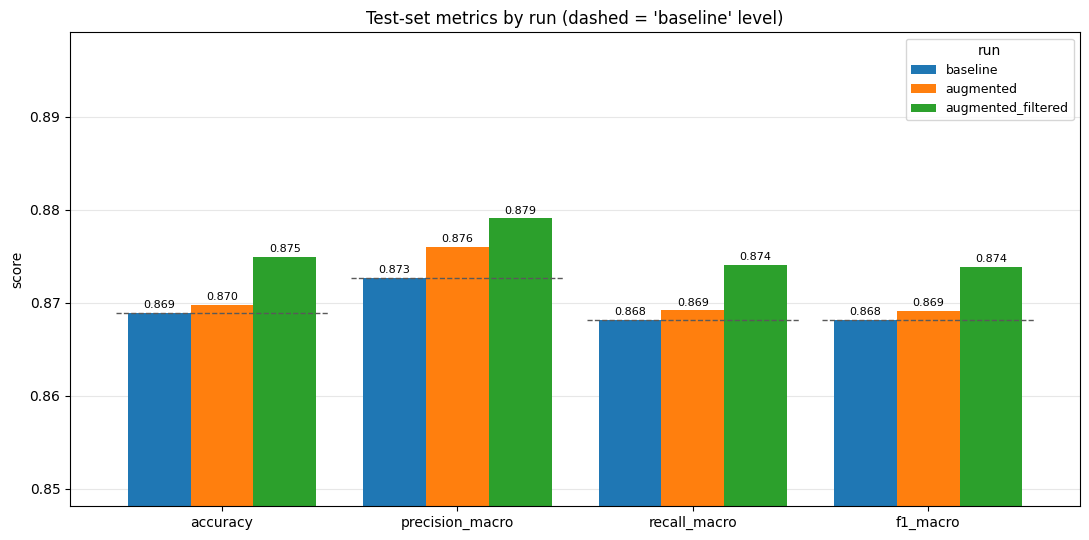

In [16]:
COMPARISON_PLOT_PATH = REPORTS_DIR / "model_comparison.png"


def plot_metric_comparison(
    comparison: pd.DataFrame, metrics: list[str], baseline_run: str, output_path: Path
) -> plt.Figure:
    """Plot the headline test metrics as grouped bars, one group per metric and one bar per run.

    Args:
        comparison: the comparison table, indexed by run.
        metrics: metric columns to chart, in display order.
        baseline_run: run drawn as the dashed reference level in each group.
        output_path: PNG file the figure is written to.

    Returns:
        plt.Figure: the rendered figure.
    """
    runs = list(comparison.index)
    palette = plt.get_cmap("tab10")
    group_centres = np.arange(len(metrics))
    bar_width = 0.8 / len(runs)

    fig, ax = plt.subplots(figsize=(11, 5.5))
    for position, run_name in enumerate(runs):
        offsets = group_centres + (position - (len(runs) - 1) / 2) * bar_width
        values = comparison.loc[run_name, metrics].astype(float)
        bars = ax.bar(offsets, values, width=bar_width, color=palette(position), label=run_name)
        ax.bar_label(bars, fmt="%.3f", fontsize=8, padding=2)

    # Dashed baseline level per metric group, so each bar is read against what it must beat.
    for centre, metric in zip(group_centres, metrics):
        level = float(comparison.loc[baseline_run, metric])
        ax.plot([centre - 0.45, centre + 0.45], [level, level], linestyle="--", linewidth=1,
                color="0.35", zorder=4)

    all_values = comparison[metrics].astype(float).to_numpy()
    margin = max(0.02, (all_values.max() - all_values.min()) * 0.6)
    ax.set_ylim(max(0.0, all_values.min() - margin), min(1.0, all_values.max() + margin))

    ax.set_xticks(group_centres)
    ax.set_xticklabels(metrics)
    ax.set_ylabel("score")
    ax.set_title(f"Test-set metrics by run (dashed = '{baseline_run}' level)")
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend(title="run", fontsize=9)

    fig.tight_layout()
    fig.savefig(output_path, dpi=150)
    print(f"Saved comparison chart to {output_path}")
    return fig


plot_metric_comparison(comparison_table, HEADLINE_METRICS, BASELINE_RUN, COMPARISON_PLOT_PATH)
plt.show()

### 6.6 Are the differences real?

The gaps in 6.4 are fractions of a point, which is exactly the size random variation produces on a 3 669-image test set — so before interpreting them, they have to be tested. The three runs score the **same** images, so the appropriate test is a paired one: for each pair of runs, count the images the first gets right and the second gets wrong (`broken`) against the images where it goes the other way (`fixed`), and ask how far that split sits from 50/50. That is McNemar's test, used here in its exact binomial form.

Alongside it, the per-breed table from 6.3 is restated as **deltas against the baseline**, and summarised three ways: by species, by how strong the baseline already was on that breed, and as a correlation between the two. A headline number can only say *how much*; the per-class structure is what says *where*, and that is what 6.7 argues from.

In [17]:
from scipy.stats import binomtest

# The 12 cat breeds of Oxford-IIIT Pet; the other 25 classes are dogs. `OxfordIIITPet` exposes the
# breed label only, so the species split is declared here rather than read back from the dataset.
CAT_BREEDS = {
    "Abyssinian", "Bengal", "Birman", "Bombay", "British Shorthair", "Egyptian Mau",
    "Maine Coon", "Persian", "Ragdoll", "Russian Blue", "Siamese", "Sphynx",
}


def compare_run_errors(
    predictions_a: pd.DataFrame, predictions_b: pd.DataFrame, run_a: str, run_b: str
) -> dict[str, float | str]:
    """Run an exact McNemar test between two runs scored on the same test images.

    Only the images the two runs disagree on carry information: under the null hypothesis that the
    training data made no difference, each disagreement is an independent coin flip.

    Args:
        predictions_a: `y_true`/`y_pred` frame of the reference run, in test-set order.
        predictions_b: `y_true`/`y_pred` frame of the compared run, in the same order.
        run_a: name of the reference run.
        run_b: name of the compared run.

    Returns:
        dict[str, float | str]: the comparison, the counts `b` fixes and breaks relative to `a`,
        their net difference and the two-sided exact p-value (1.0 when the runs never disagree).
    """
    correct_a = predictions_a["y_true"] == predictions_a["y_pred"]
    correct_b = predictions_b["y_true"] == predictions_b["y_pred"]
    fixed = int((~correct_a & correct_b).sum())
    broken = int((correct_a & ~correct_b).sum())
    discordant = fixed + broken

    return {
        "comparison": f"{run_a} -> {run_b}",
        "fixed": fixed,
        "broken": broken,
        "net": fixed - broken,
        "p_value": binomtest(fixed, discordant, 0.5).pvalue if discordant else 1.0,
    }


def build_per_class_deltas(
    per_class: pd.DataFrame, baseline_run: str, cat_breeds: set[str]
) -> pd.DataFrame:
    """Restate per-breed F1 as each run's change against the baseline run.

    Args:
        per_class: the long per-class metrics frame from 6.3 (`run, class_label, f1, ...`).
        baseline_run: run every other run is differenced against.
        cat_breeds: breed names belonging to the cat species, used for the species column.

    Returns:
        pd.DataFrame: one row per breed, holding the baseline F1, its species, and one
        `delta_<run>` column per non-baseline run.
    """
    f1_by_run = per_class.pivot(index="class_label", columns="run", values="f1")
    deltas = pd.DataFrame(
        {"baseline_f1": f1_by_run[baseline_run]},
        index=f1_by_run.index,
    )
    deltas["species"] = np.where(deltas.index.isin(cat_breeds), "cat", "dog")
    for run_name in f1_by_run.columns.drop(baseline_run):
        deltas[f"delta_{run_name}"] = f1_by_run[run_name] - f1_by_run[baseline_run]
    return deltas.sort_values(deltas.columns[-1])


def summarise_delta_structure(deltas: pd.DataFrame, delta_column: str, group_size: int) -> None:
    """Print where a run's per-class gains landed: by species, and by baseline strength.

    Args:
        deltas: the frame built by `build_per_class_deltas`.
        delta_column: the `delta_<run>` column to summarise.
        group_size: how many breeds form the "weakest" and "strongest" baseline groups.
    """
    by_baseline = deltas.sort_values("baseline_f1")
    improved = int((deltas[delta_column] > 0).sum())
    print(f"{delta_column}: {improved} of {len(deltas)} breeds improved")
    print(f"  by species (mean delta): "
          f"{deltas.groupby('species')[delta_column].mean().round(4).to_dict()}")
    print(f"  weakest {group_size} baseline breeds: {by_baseline.head(group_size)[delta_column].mean():+.4f}"
          f"   strongest {group_size}: {by_baseline.tail(group_size)[delta_column].mean():+.4f}")
    print(f"  corr(baseline F1, delta): {deltas['baseline_f1'].corr(deltas[delta_column]):+.3f}")


run_names = list(run_predictions)
significance = pd.DataFrame(
    [
        compare_run_errors(run_predictions[run_a], run_predictions[run_b], run_a, run_b)
        for run_a, run_b in [
            (BASELINE_RUN, "augmented"),
            (BASELINE_RUN, "augmented_filtered"),
            ("augmented", "augmented_filtered"),
        ]
    ]
).set_index("comparison")

per_class_deltas = build_per_class_deltas(per_class_metrics, BASELINE_RUN, CAT_BREEDS)
for run_name in run_names:
    if run_name != BASELINE_RUN:
        summarise_delta_structure(per_class_deltas, f"delta_{run_name}", group_size=10)

print("\nPaired McNemar tests (positive net = the second run is ahead):")
significance.round(4)

delta_augmented: 13 of 37 breeds improved
  by species (mean delta): {'cat': 0.002, 'dog': 0.0006}
  weakest 10 baseline breeds: +0.0149   strongest 10: -0.0052
  corr(baseline F1, delta): -0.296
delta_augmented_filtered: 19 of 37 breeds improved
  by species (mean delta): {'cat': 0.0133, 'dog': 0.0021}
  weakest 10 baseline breeds: +0.0255   strongest 10: -0.0076
  corr(baseline F1, delta): -0.381

Paired McNemar tests (positive net = the second run is ahead):


,fixed,broken,net,p_value
comparison,,,,
baseline -> augmented,100,97,3,0.8867
baseline -> augmented_filtered,104,82,22,0.1234
augmented -> augmented_filtered,106,87,19,0.1950


### 6.7 Discussion

**Does the pipeline help?** Yes, but only after filtering, and only modestly on this task.

| Run | Train images | Accuracy | Macro-F1 | vs baseline (McNemar) |
|---|---|---|---|---|
| baseline | 2,944 real | 0.8689 | 0.8681 | — |
| augmented | +1,870 synthetic | 0.8697 | 0.8691 | p = 0.887 |
| augmented_filtered | +1,452 filtered synthetic | **0.8749** | **0.8739** | p = 0.123 |

**The filter is the finding.** Unfiltered synthetic data added net 3 correct predictions out of 3,669 — no effect. Filtering out the 418 images (22.4%) that fell >1.5σ below their class's CLIP baseline turned that into +0.6pp accuracy/F1, a better validation optimum reached in fewer epochs, and a majority of breeds (19/37) improving vs. only 13/37 unfiltered. A two-run experiment would have concluded "synthetic data doesn't help" — wrong.

**How solid is +0.6pp?** Not significant alone (p = 0.123, n=22 flipped images), but the pattern is structured, not noise: it holds across all four headline metrics simultaneously, correlates with baseline weakness (r = −0.38 — weak breeds gained most, strong breeds slightly lost), and the biggest wins (Beagle +7.6pp, Bengal +5.9pp) are large individual moves, not scattered jitter. Suggestive, not proven.

**Why the gain is small: this is the hard case.** Breed classification hinges on fine detail (coat, muzzle, ear shape) that img2img is worst at preserving — CLIP scores show synthetic images drift furthest from class identity on exactly the long-coated/pattern-heavy breeds (up to 69.8% flagged). This is also why breed-injection into captions is essential: without it (an earlier pre-filter run), BLIP's generic captions ("a dog on a couch") let diffusion drop breed identity entirely, and the resulting model scored *below* baseline.

**Implication for coarser tasks.** Species-level or other coarse-grained targets rely on features (skull/body shape) that img2img preserves well, so the same pipeline should generalize much better there; this fine-grained result is a lower bound, not a ceiling. A cats-vs-dogs split in the data hints at this (cats +1.33pp vs dogs +0.21pp) but is confounded with baseline strength, so it's not proof.

**Bottom line:** the pipeline only works because three points in it re-attach class identity that upstream models don't know exists — the caption gate, breed injection, and image gate. Remove any one (as an earlier run did) and the pipeline still runs, still looks fine, and silently produces a worse classifier.

In [19]:
best_run = comparison_table["f1_macro"].astype(float).idxmax()

print("Section 6 complete — artifacts on disk:")
for run_name in run_predictions:
    print(f"  {REPORTS_DIR}/test_predictions_{run_name}.csv : {len(run_predictions[run_name])} test predictions")
print(f"  {PER_CLASS_METRICS_PATH} : per-breed metrics for all {len(run_predictions)} runs")
print(f"  {COMPARISON_TABLE_PATH} : the comparison table above")
print(f"  {COMPARISON_PLOT_PATH} : the comparison chart above")
print(
    f"\nBest macro-F1 on the held-out test set: '{best_run}' "
    f"({comparison_table.loc[best_run, 'f1_macro']:.4f})"
)
print("Pipeline complete.")

Section 6 complete — artifacts on disk:
  reports/test_predictions_baseline.csv : 3669 test predictions
  reports/test_predictions_augmented.csv : 3669 test predictions
  reports/test_predictions_augmented_filtered.csv : 3669 test predictions
  reports/per_class_metrics.csv : per-breed metrics for all 3 runs
  reports/model_comparison.csv : the comparison table above
  reports/model_comparison.png : the comparison chart above

Best macro-F1 on the held-out test set: 'augmented_filtered' (0.8739)
Pipeline complete.
